# Personalized Workout Recommendation Model

## Dataset Description

This project uses three datasets to build a personalized workout recommendation system.

### 1. Fitbit Fitness Tracker Data
This dataset contains real-world fitness tracker data collected from Fitbit devices. It includes information about users' daily activities such as steps taken, calories burned, activity intensity, and sleep patterns. The dataset helps analyze user lifestyle and physical activity behavior.

### 2. Gym Exercise Dataset
This dataset provides a collection of gym exercises along with details such as target muscle groups, equipment used, and difficulty level. It will serve as the exercise library for generating workout recommendations.

### 3. Body Fat Prediction Dataset
This dataset contains body measurement information including weight, body fat percentage, and other physical attributes. It helps incorporate body composition factors when generating personalized workout recommendations.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteCaloriesNarrow_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/weightLogInfo_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteMETsNarrow_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlyCalories_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/heartrate_seconds_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteSleep_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlyIntensities_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitaba

In [2]:
# Body Fat dataset
bodyfat = pd.read_csv("/kaggle/input/datasets/fedesoriano/body-fat-prediction-dataset/bodyfat.csv")

# Gym Exercise dataset
exercise = pd.read_csv("/kaggle/input/datasets/niharika41298/gym-exercise-data/megaGymDataset.csv")

# Fitbit datasets
daily_activity = pd.read_csv("/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv")

sleep_data = pd.read_csv("/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv")

weight_data = pd.read_csv("/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/weightLogInfo_merged.csv")

In [3]:
daily_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [7]:
sleep_data.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


In [8]:
weight_data.head()

,Id,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
0,1503960366,5/2/2016 11:59:59 PM,52.599998,115.963147,22.0,22.650000,True,1462233599000
1,1503960366,5/3/2016 11:59:59 PM,52.599998,115.963147,NaN,22.650000,True,1462319999000
2,1927972279,4/13/2016 1:08:52 AM,133.500000,294.317120,NaN,47.540001,False,1460509732000
3,2873212765,4/21/2016 11:59:59 PM,56.700001,125.002104,NaN,21.450001,True,1461283199000
4,2873212765,5/12/2016 11:59:59 PM,57.299999,126.324875,NaN,21.690001,True,1463097599000


In [4]:
exercise.head()

,Unnamed: 0,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
0,0,Partner plank band row,The partner plank band row is an abdominal exe...,Strength,Abdominals,Bands,Intermediate,0.0,NaN
1,1,Banded crunch isometric hold,The banded crunch isometric hold is an exercis...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
2,2,FYR Banded Plank Jack,The banded plank jack is a variation on the pl...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
3,3,Banded crunch,The banded crunch is an exercise targeting the...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
4,4,Crunch,The crunch is a popular core exercise targetin...,Strength,Abdominals,Bands,Intermediate,NaN,NaN


In [5]:
bodyfat.head()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


## Data Exploration

In this step, the structure of each dataset is explored to understand the number of records, features, data types, and basic statistical properties. This helps in identifying important variables and potential data quality issues before preprocessing.

In [6]:
daily_activity.shape

(940, 15)

In [5]:
daily_activity.columns

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'],
      dtype='object')

In [7]:
daily_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories  

In [8]:
daily_activity.describe()

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,9.400000e+02,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,4.855407e+09,7637.910638,5.489702,5.475351,0.108171,1.502681,0.567543,3.340819,0.001606,21.164894,13.564894,192.812766,991.210638,2303.609574
std,2.424805e+09,5087.150742,3.924606,3.907276,0.619897,2.658941,0.883580,2.040655,0.007346,32.844803,19.987404,109.174700,301.267437,718.166862
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.320127e+09,3789.750000,2.620000,2.620000,0.000000,0.000000,0.000000,1.945000,0.000000,0.000000,0.000000,127.000000,729.750000,1828.500000
50%,4.445115e+09,7405.500000,5.245000,5.245000,0.000000,0.210000,0.240000,3.365000,0.000000,4.000000,6.000000,199.000000,1057.500000,2134.000000
75%,6.962181e+09,10727.000000,7.712500,7.710000,0.000000,2.052500,0.800000,4.782500,0.000000,32.000000,19.000000,264.000000,1229.500000,2793.250000
max,8.877689e+09,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,143.000000,518.000000,1440.000000,4900.000000


In [10]:
sleep_data.shape

(413, 5)

In [11]:
sleep_data.columns

Index(['Id', 'SleepDay', 'TotalSleepRecords', 'TotalMinutesAsleep',
       'TotalTimeInBed'],
      dtype='object')

In [12]:
sleep_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Id                  413 non-null    int64 
 1   SleepDay            413 non-null    object
 2   TotalSleepRecords   413 non-null    int64 
 3   TotalMinutesAsleep  413 non-null    int64 
 4   TotalTimeInBed      413 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 16.3+ KB


In [13]:
sleep_data.describe()

,Id,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
count,4.130000e+02,413.000000,413.000000,413.000000
mean,5.000979e+09,1.118644,419.467312,458.639225
std,2.060360e+09,0.345521,118.344679,127.101607
min,1.503960e+09,1.000000,58.000000,61.000000
25%,3.977334e+09,1.000000,361.000000,403.000000
50%,4.702922e+09,1.000000,433.000000,463.000000
75%,6.962181e+09,1.000000,490.000000,526.000000
max,8.792010e+09,3.000000,796.000000,961.000000


In [15]:
weight_data.shape

(67, 8)

In [16]:
weight_data.columns

Index(['Id', 'Date', 'WeightKg', 'WeightPounds', 'Fat', 'BMI',
       'IsManualReport', 'LogId'],
      dtype='object')

In [17]:
weight_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              67 non-null     int64  
 1   Date            67 non-null     object 
 2   WeightKg        67 non-null     float64
 3   WeightPounds    67 non-null     float64
 4   Fat             2 non-null      float64
 5   BMI             67 non-null     float64
 6   IsManualReport  67 non-null     bool   
 7   LogId           67 non-null     int64  
dtypes: bool(1), float64(4), int64(2), object(1)
memory usage: 3.9+ KB


In [18]:
weight_data.describe()

,Id,WeightKg,WeightPounds,Fat,BMI,LogId
count,6.700000e+01,67.000000,67.000000,2.00000,67.000000,6.700000e+01
mean,7.009282e+09,72.035821,158.811801,23.50000,25.185224,1.461772e+12
std,1.950322e+09,13.923206,30.695415,2.12132,3.066963,7.829948e+08
min,1.503960e+09,52.599998,115.963147,22.00000,21.450001,1.460444e+12
25%,6.962181e+09,61.400002,135.363832,22.75000,23.959999,1.461079e+12
50%,6.962181e+09,62.500000,137.788914,23.50000,24.389999,1.461802e+12
75%,8.877689e+09,85.049999,187.503152,24.25000,25.559999,1.462375e+12
max,8.877689e+09,133.500000,294.317120,25.00000,47.540001,1.463098e+12


In [19]:
exercise.shape

(2918, 9)

In [20]:
exercise.columns

Index(['Unnamed: 0', 'Title', 'Desc', 'Type', 'BodyPart', 'Equipment', 'Level',
       'Rating', 'RatingDesc'],
      dtype='object')

In [21]:
exercise.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2918 entries, 0 to 2917
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2918 non-null   int64  
 1   Title       2918 non-null   object 
 2   Desc        1368 non-null   object 
 3   Type        2918 non-null   object 
 4   BodyPart    2918 non-null   object 
 5   Equipment   2886 non-null   object 
 6   Level       2918 non-null   object 
 7   Rating      1031 non-null   float64
 8   RatingDesc  862 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 205.3+ KB


In [25]:
exercise.describe()

,Unnamed: 0,Rating
count,2918.000000,1031.000000
mean,1458.500000,5.919690
std,842.498368,3.584607
min,0.000000,0.000000
25%,729.250000,3.000000
50%,1458.500000,7.900000
75%,2187.750000,8.700000
max,2917.000000,9.600000


In [31]:
bodyfat.shape

(252, 15)

In [32]:
bodyfat.columns

Index(['Density', 'BodyFat', 'Age', 'Weight', 'Height', 'Neck', 'Chest',
       'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm',
       'Wrist'],
      dtype='object')

In [33]:
bodyfat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


In [7]:
bodyfat.describe()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,19.150794,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762
std,0.019031,8.368740,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585
min,0.995000,0.000000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041400,12.475000,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000
50%,1.054900,19.200000,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000
75%,1.070400,25.300000,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000
max,1.108900,47.500000,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


# Data Visualizations

## Fitbit Daily Activity Visualizations

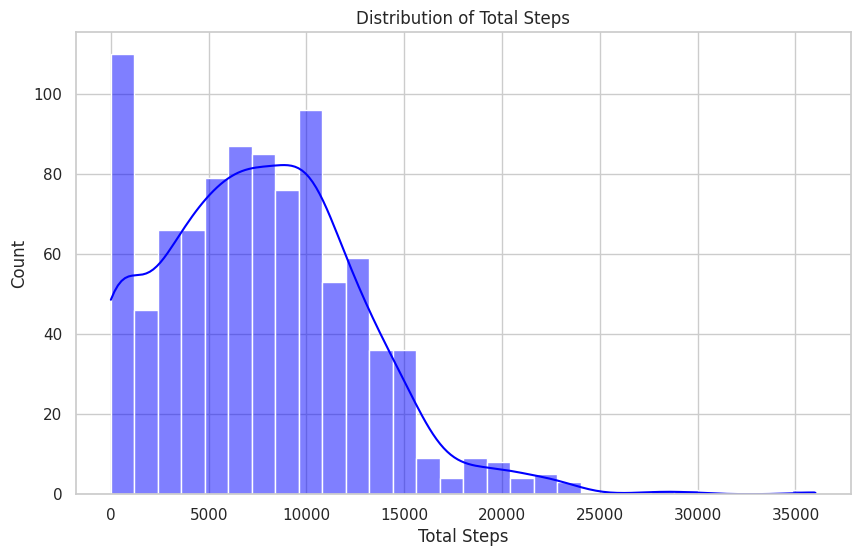

In [11]:
# Total Steps Distribution
sns.histplot(daily_activity['TotalSteps'], bins=30, kde=True, color='blue')
plt.title("Distribution of Total Steps")
plt.xlabel("Total Steps")
plt.ylabel("Count")
plt.show()

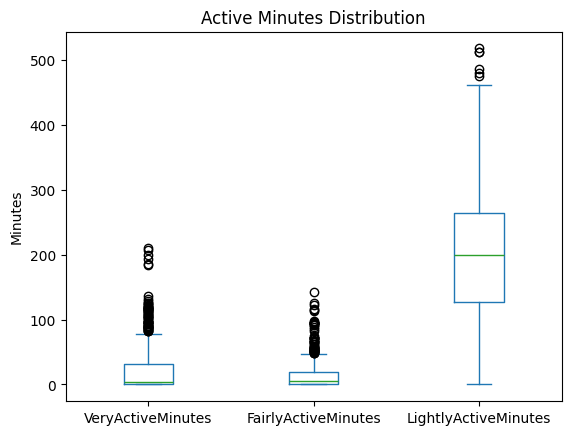

In [3]:
# Active Minutes (VeryActive, FairlyActive, LightlyActive)
active_cols = ['VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes']
daily_activity[active_cols].plot(kind='box')
plt.title("Active Minutes Distribution")
plt.ylabel("Minutes")
plt.show()

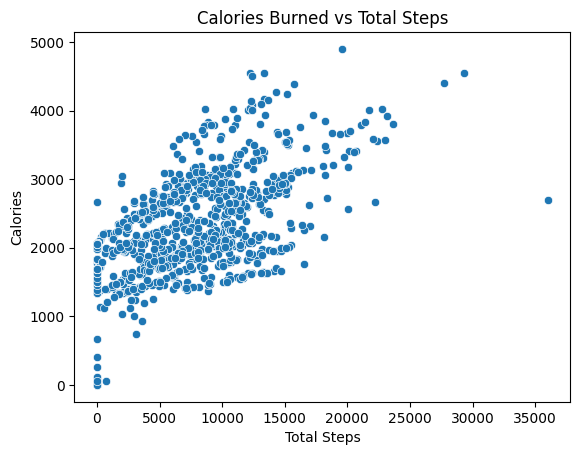

In [4]:
# Calories vs Steps Scatter
sns.scatterplot(x='TotalSteps', y='Calories', data=daily_activity)
plt.title("Calories Burned vs Total Steps")
plt.xlabel("Total Steps")
plt.ylabel("Calories")
plt.show()

## Sleep Data Visualizations

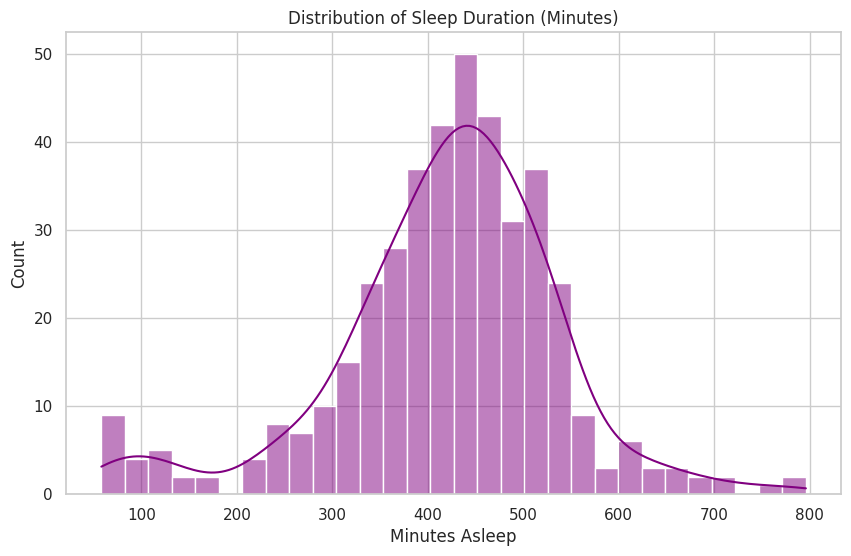

In [14]:
sns.histplot(sleep_data['TotalMinutesAsleep'], bins=30, kde=True, color='purple')
plt.title("Distribution of Sleep Duration (Minutes)")
plt.xlabel("Minutes Asleep")
plt.ylabel("Count")
plt.show()

## Weight Dataset Visualizations

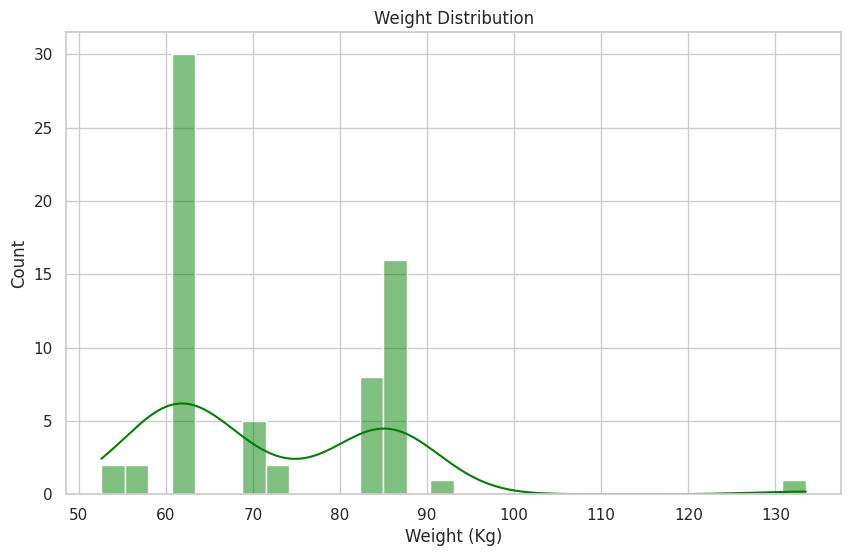

In [16]:
sns.histplot(weight_data['WeightKg'], bins=30, kde=True, color='green')
plt.title("Weight Distribution")
plt.xlabel("Weight (Kg)")
plt.ylabel("Count")
plt.show()

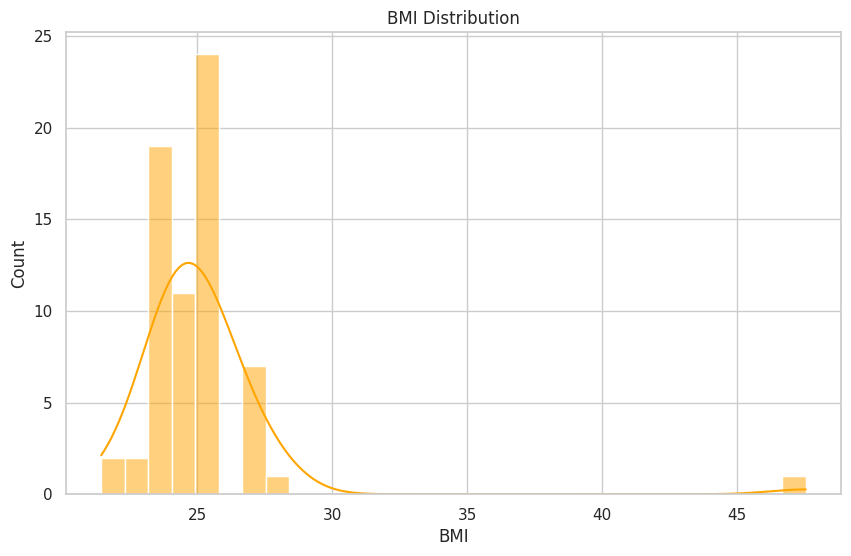

In [18]:
sns.histplot(weight_data['BMI'], bins=30, kde=True, color='orange')
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

## Body Fat Dataset

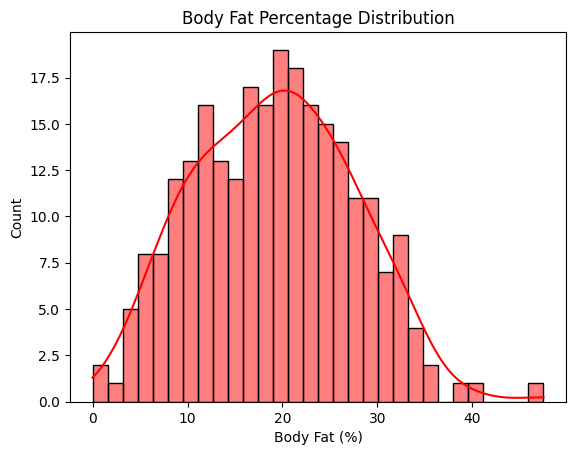

In [5]:
sns.histplot(bodyfat['BodyFat'], bins=30, kde=True, color='red')
plt.title("Body Fat Percentage Distribution")
plt.xlabel("Body Fat (%)")
plt.ylabel("Count")
plt.show()

## Gym Exercise Dataset

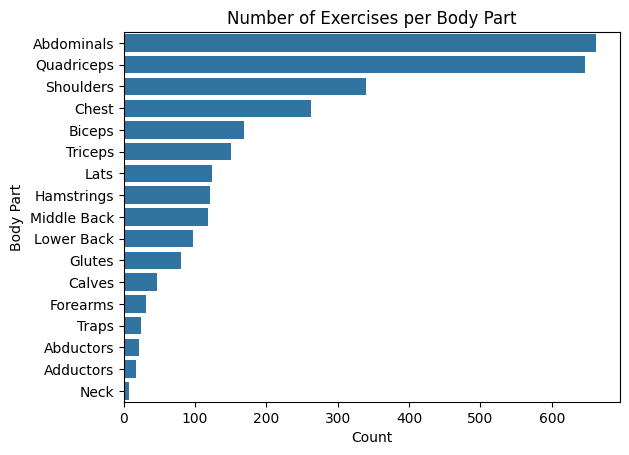

In [6]:
# Exercises per Body Part
sns.countplot(y='BodyPart', data=exercise, order=exercise['BodyPart'].value_counts().index)
plt.title("Number of Exercises per Body Part")
plt.xlabel("Count")
plt.ylabel("Body Part")
plt.show()

## Data Preprocessing

In this step, data cleaning techniques were applied to improve data quality.

- Missing values were identified and handled by removing incomplete records.
- Duplicate entries were removed to ensure data consistency.
- Date columns were converted into proper datetime format for easier analysis.

These steps help prepare the dataset for further analysis and model development.

In [7]:
daily_activity.isnull().sum()

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

In [8]:
sleep_data.isnull().sum()

Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64

In [10]:
weight_data.isnull().sum()

Id                 0
Date               0
WeightKg           0
WeightPounds       0
Fat               65
BMI                0
IsManualReport     0
LogId              0
dtype: int64

In [11]:
weight_data = weight_data.drop(columns=["Fat"])

In [16]:
weight_data.isnull().sum()

Id                0
Date              0
WeightKg          0
WeightPounds      0
BMI               0
IsManualReport    0
LogId             0
dtype: int64

In [12]:
exercise.isnull().sum()

Unnamed: 0       0
Title            0
Desc          1550
Type             0
BodyPart         0
Equipment       32
Level            0
Rating        1887
RatingDesc    2056
dtype: int64

In [13]:
exercise = exercise.drop(columns=["Desc", "Rating", "RatingDesc"])

In [14]:
exercise = exercise.dropna()

In [17]:
exercise.isnull().sum()

Unnamed: 0    0
Title         0
Type          0
BodyPart      0
Equipment     0
Level         0
dtype: int64

In [34]:
bodyfat.isnull().sum()

Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64

#### Remove duplicates

In [20]:
daily_activity = daily_activity.drop_duplicates()
sleep_data = sleep_data.drop_duplicates()
weight_data = weight_data.drop_duplicates()
exercise = exercise.drop_duplicates()
bodyfat = bodyfat.drop_duplicates()

#### Fix Data Types

In [21]:
daily_activity['ActivityDate'] = pd.to_datetime(daily_activity['ActivityDate'])

sleep_data['SleepDay'] = pd.to_datetime(sleep_data['SleepDay'])

weight_data['Date'] = pd.to_datetime(weight_data['Date'])

/tmp/ipykernel_56/2527813136.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep_data['SleepDay'] = pd.to_datetime(sleep_data['SleepDay'])
/tmp/ipykernel_56/2527813136.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weight_data['Date'] = pd.to_datetime(weight_data['Date'])


Removing time

In [22]:
sleep_data['SleepDay'] = sleep_data['SleepDay'].dt.date
daily_activity['ActivityDate'] = daily_activity['ActivityDate'].dt.date
weight_data['Date'] = weight_data['Date'].dt.date

In [23]:
print(type(daily_activity['ActivityDate'][0]))
print(type(sleep_data['SleepDay'][0]))
print(type(weight_data['Date'][0]))

<class 'datetime.date'>
<class 'datetime.date'>
<class 'datetime.date'>


## Data Merging

The Fitbit datasets were merged to create a unified dataset for analysis.

- The `daily_activity`, `sleep_data`, and `weight_data` datasets were merged using common columns (`Id` and date).
- Date columns were converted into a consistent format before merging.
- A left join was used to retain all activity records while incorporating sleep and weight information.

This merged dataset represents a comprehensive view of user activity, sleep behavior, and body metrics.

In [24]:
fitbit_data = pd.merge(
    daily_activity,
    sleep_data,
    left_on=["Id", "ActivityDate"],
    right_on=["Id", "SleepDay"],
    how="left"
)

In [25]:
fitbit_data = pd.merge(
    fitbit_data,
    weight_data,
    left_on=["Id", "ActivityDate"],
    right_on=["Id", "Date"],
    how="left"
)

In [26]:
fitbit_data = fitbit_data.drop(columns=["SleepDay", "Date"])

In [27]:
fitbit_data.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,SedentaryMinutes,Calories,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,WeightKg,WeightPounds,BMI,IsManualReport,LogId
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,...,728,1985,1.0,327.0,346.0,NaN,NaN,NaN,NaN,NaN
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,...,776,1797,2.0,384.0,407.0,NaN,NaN,NaN,NaN,NaN
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,...,1218,1776,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,...,726,1745,1.0,412.0,442.0,NaN,NaN,NaN,NaN,NaN
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,...,773,1863,2.0,340.0,367.0,NaN,NaN,NaN,NaN,NaN


In [28]:
fitbit_data.shape

(940, 23)

In [29]:
fitbit_data.isnull().sum()

Id                            0
ActivityDate                  0
TotalSteps                    0
TotalDistance                 0
TrackerDistance               0
LoggedActivitiesDistance      0
VeryActiveDistance            0
ModeratelyActiveDistance      0
LightActiveDistance           0
SedentaryActiveDistance       0
VeryActiveMinutes             0
FairlyActiveMinutes           0
LightlyActiveMinutes          0
SedentaryMinutes              0
Calories                      0
TotalSleepRecords           530
TotalMinutesAsleep          530
TotalTimeInBed              530
WeightKg                    873
WeightPounds                873
BMI                         873
IsManualReport              873
LogId                       873
dtype: int64

In [32]:
fitbit_data["TotalMinutesAsleep"] = fitbit_data["TotalMinutesAsleep"].fillna(0)
fitbit_data["TotalTimeInBed"] = fitbit_data["TotalTimeInBed"].fillna(0)
fitbit_data["TotalSleepRecords"] = fitbit_data["TotalSleepRecords"].fillna(0)

In [33]:
fitbit_data["WeightKg"] = fitbit_data["WeightKg"].fillna(fitbit_data["WeightKg"].mean())
fitbit_data["BMI"] = fitbit_data["BMI"].fillna(fitbit_data["BMI"].mean())

In [34]:
fitbit_data = fitbit_data.drop(columns=["LogId", "IsManualReport", "WeightPounds"])

In [35]:
fitbit_data.isnull().sum()

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
TotalSleepRecords           0
TotalMinutesAsleep          0
TotalTimeInBed              0
WeightKg                    0
BMI                         0
dtype: int64

## Data Visualization (After Preprocessing)

After cleaning and merging the datasets, data visualization was performed to understand relationships between key features.

- A correlation heatmap was used to identify relationships between variables such as steps, calories, and BMI.
- Scatter plots showed strong relationships between physical activity (steps, active minutes) and calories burned.
- Sleep patterns were analyzed to observe how activity levels influence sleep duration.
- Distributions of BMI and steps helped in understanding user fitness levels.
- Exercise dataset visualization highlighted the distribution of exercises across body parts and difficulty levels.

These insights help in selecting important features for building a personalized workout recommendation system.

### Correlation Heatmap

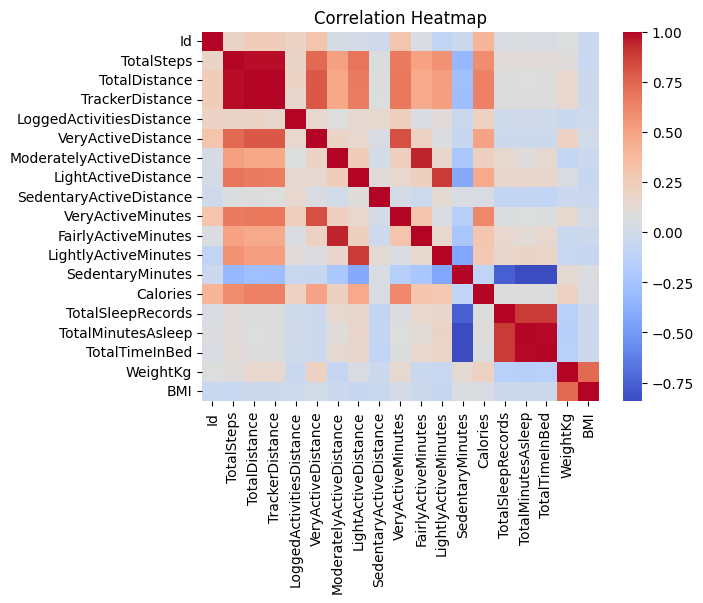

In [36]:
corr = fitbit_data.corr(numeric_only=True)

sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Steps vs Calories

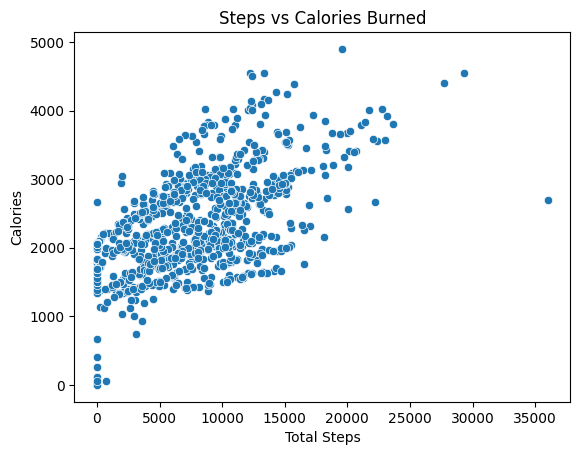

In [37]:
sns.scatterplot(x='TotalSteps', y='Calories', data=fitbit_data)
plt.title("Steps vs Calories Burned")
plt.xlabel("Total Steps")
plt.ylabel("Calories")
plt.show()

### Activity Level Distribution

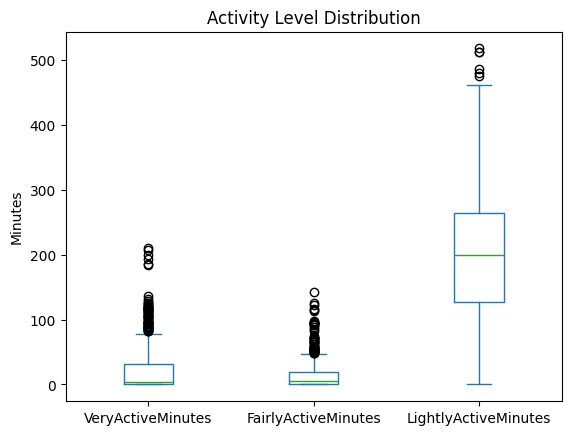

In [38]:
activity_cols = ['VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes']

fitbit_data[activity_cols].plot(kind='box')
plt.title("Activity Level Distribution")
plt.ylabel("Minutes")
plt.show()

### Sleep Analysis

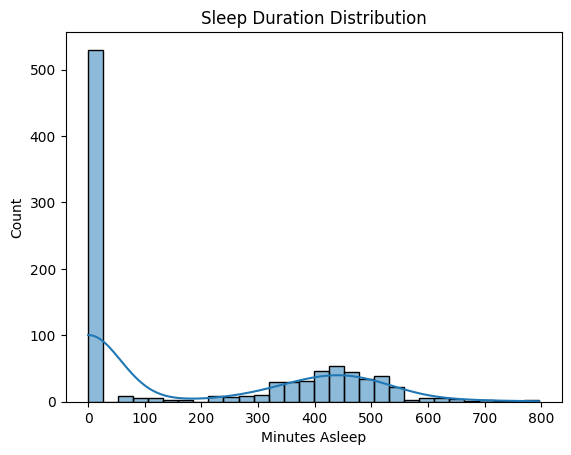

In [39]:
sns.histplot(fitbit_data['TotalMinutesAsleep'], bins=30, kde=True)
plt.title("Sleep Duration Distribution")
plt.xlabel("Minutes Asleep")
plt.show()

### Sleep vs Activity

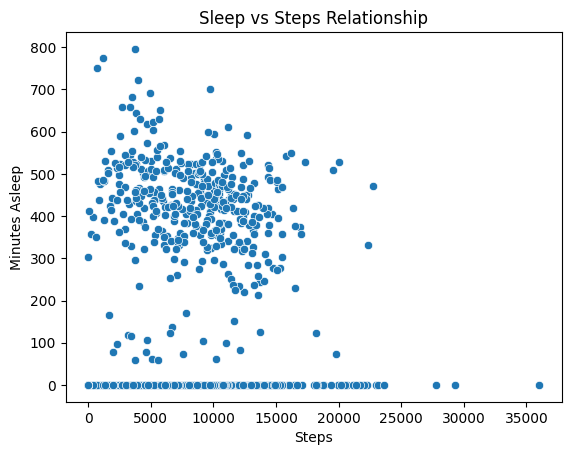

In [40]:
sns.scatterplot(x='TotalSteps', y='TotalMinutesAsleep', data=fitbit_data)
plt.title("Sleep vs Steps Relationship")
plt.xlabel("Steps")
plt.ylabel("Minutes Asleep")
plt.show()

### BMI Distribution

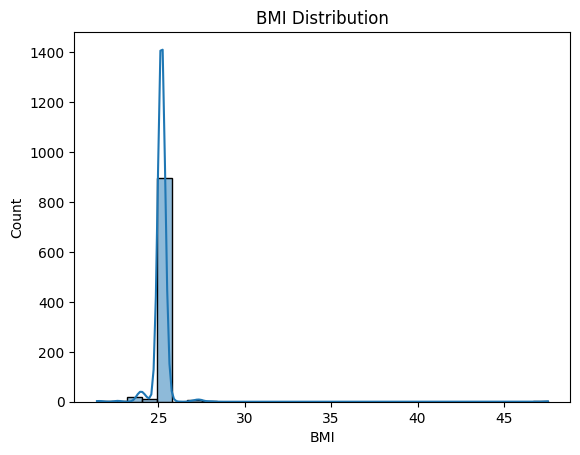

In [41]:
sns.histplot(fitbit_data['BMI'], bins=30, kde=True)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.show()

### Active Minutes vs Calories

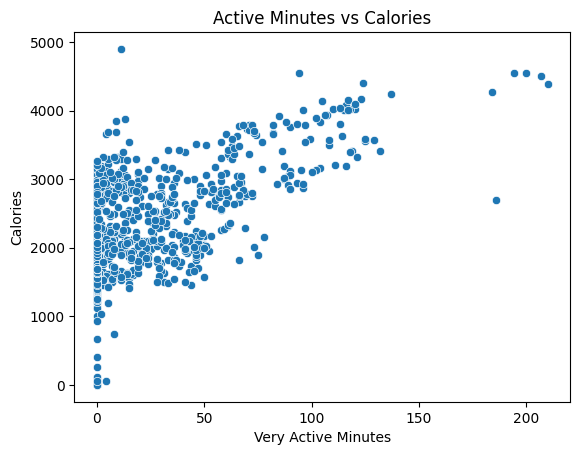

In [42]:
sns.scatterplot(x='VeryActiveMinutes', y='Calories', data=fitbit_data)
plt.title("Active Minutes vs Calories")
plt.xlabel("Very Active Minutes")
plt.ylabel("Calories")
plt.show()

### Steps Distribution

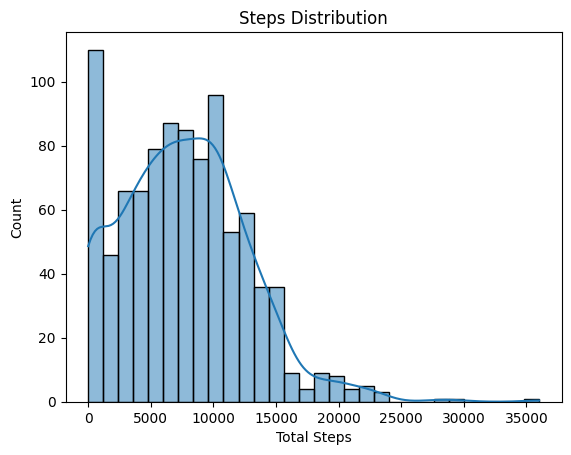

In [43]:
sns.histplot(fitbit_data['TotalSteps'], bins=30, kde=True)
plt.title("Steps Distribution")
plt.xlabel("Total Steps")
plt.show()

### Exercise Dataset

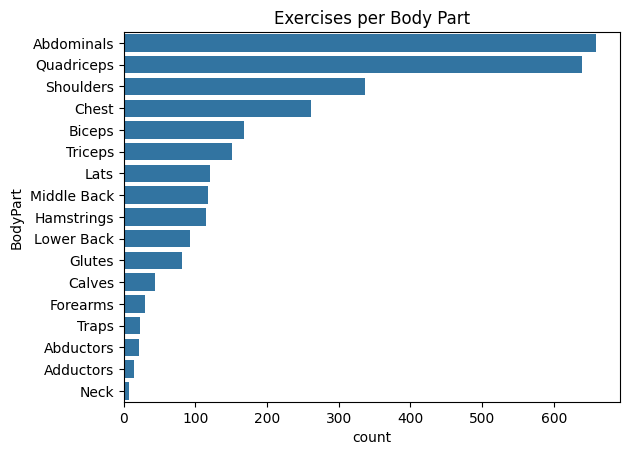

In [44]:
sns.countplot(y='BodyPart', data=exercise, order=exercise['BodyPart'].value_counts().index)
plt.title("Exercises per Body Part")
plt.show()